# Load modules

In [62]:
import os
from glob import glob 
import xarray as xr
import numpy as np
import pyproj

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt 
import cmocean 
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.ticker import MaxNLocator, FixedLocator, FixedFormatter

from gsw import f
from scipy import stats

# Define directories

In [67]:
path_current = os.getcwd()
path_data = os.path.join(path_current, 'Fields_INALT60/')
path_SWOT = '/Users/solangecoadou/Desktop/Desktop/Thesis/GRL_2026_SWOT_SQG/DATA/Swot_fast_sampling/'
path_SWOT_science_phase = '/Users/solangecoadou/Desktop/Desktop/Thesis/GRL_2026_SWOT_SQG/DATA/Swot_science_phase/'

# Read data

In [40]:
field_model = xr.open_dataset(path_data+'INALT60_zeta_w_strain.nc')
RMS_model = xr.open_dataset(path_data+'RMS_timeseries_INALT60.nc')
ssh_model = xr.open_dataset(path_data+'INALT60_ssh.nc')
bathy = xr.open_dataset(path_data+'bathy_INALT60.nc')

file_swot = [x for x in glob(path_SWOT+'*.nc')] 
file_swot.sort()

# Grid eSQG model

In [46]:
lon_c=15.7
lat_c=-37.8

pos_west,pos_east,pos_south,pos_north  = lon_c-2,lon_c+2,lat_c-2,lat_c+2

bathy_region=bathy.where((bathy.nav_lat>pos_south-1.2) & (bathy.nav_lat<pos_north+1.2) & (bathy.nav_lon>pos_west-1.2) & (bathy.nav_lon<pos_east+1.2), drop=True)

dx=2
lon_grid=bathy_region.nav_lon
lat_grid=bathy_region.nav_lat

#Define the grid
a = pyproj.Transformer.from_crs(4326,3395).transform(lon_grid,lat_grid) # project WGS84 onto metric grid
y3 = a[0]
x3 = a[1]
x3min = np.nanmin(x3,1)
y3min = np.nanmin(y3,0)
Y3min,X3min = np.meshgrid(y3min, x3min)
x1=(x3-X3min)/1000
y1=(y3-Y3min)/1000
x_len = int(np.floor(np.amax(x1))+1)
y_len = int(np.floor(np.amax(y1))+1)
x_dim = np.linspace(0, x_len, int(x_len/dx), endpoint=False)
y_dim = np.linspace(0, y_len, int(y_len/dx), endpoint=False)
x2, y2 = np.meshgrid(x_dim, y_dim)
    
#Add nav_lon and nav_lat back from the interpolation 
x2_proj = x2*1000 + x3min[0]
y2_proj = y2*1000 + y3min[0]
transformer_back = pyproj.Transformer.from_crs(3395, 4326, always_xy=True)
lat2, lon2 = transformer_back.transform(y2_proj,x2_proj)

#Make square - for SQG
size_x=len(lon2[0,:])
size_y=len(lon2[:,0])

if size_y>size_x:
    delta_points=size_y-size_x
    lon2 = lon2[:size_x,:]
    lat2 = lat2[:size_x,:]
else:
    delta_points=size_x-size_y
    lon2 = lon2[:,:size_y]
    lat2 = lat2[:,:size_y]
lonBIG, latBIG = lon2, lat2
lon2, lat2 = lon2[50:-50,50:-50], lat2[50:-50,50:-50]

# Plot figure

/var/folders/gb/7q2cybx53vsb8lvgk2rgvjqm0000gn/T/ipykernel_56060/3613471229.py:178: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax5.xaxis.set_major_formatter(x_formatter)


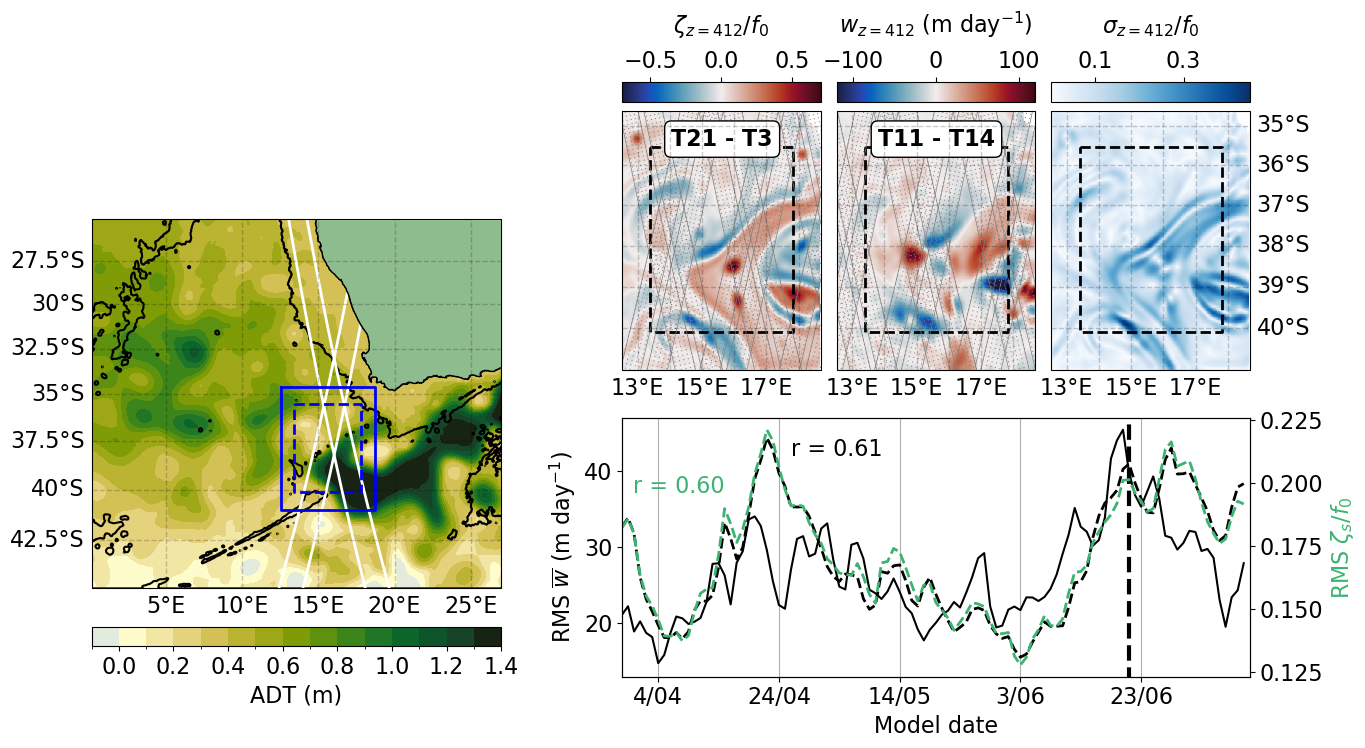

In [69]:
#Define parameters
ft=16
pos_west,pos_east,pos_south,pos_north  = 0.1,27,-44.8,-25  #Reset the area
proj = ccrs.Mercator(central_longitude=(pos_west+pos_east)/2,min_latitude=pos_south,max_latitude=pos_north)
crs = ccrs.PlateCarree()
extent=[pos_west, pos_east, pos_south, pos_north]
cartmap = proj,crs,extent

#Start figure
fig = plt.figure()

    #Plot SSH map
axs=plt.axes(projection=proj)
axs.add_feature(cfeature.LAND,linewidth=0.5,zorder=4, edgecolor='black', facecolor='darkseagreen')#,alpha=0.1)
axs.coastlines(resolution='10m', color='k', linestyle='-', alpha=1,zorder=5)
axs.set_extent(extent)
map_grid=axs.gridlines(linewidth=1, color='black', alpha=0.2, linestyle='--', draw_labels=True,zorder=6)
map_grid.top_labels = False
map_grid.right_labels = False
map_grid.left_labels = True
map_grid.xlabel_style = {'size': ft}
map_grid.ylabel_style = {'size': ft}

        #Colorbar
Tinc=np.arange(-0.1,1.5, 0.1)
cmap1 = cmocean.tools.crop(cmocean.cm.delta, vmin=Tinc[0], vmax=Tinc[-1], pivot=0)
newcolors = cmap1(np.linspace(0, 1, len(Tinc)))
pos = np.where(Tinc>=0)[0][0]
white = np.array([1, 1, 1, 1])
newcolors[pos-2:pos, :] = white
cmap = ListedColormap(newcolors)
levels = MaxNLocator(nbins=len(Tinc)).tick_values(Tinc[0], Tinc[-1])
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True) 

im = axs.pcolormesh(ssh_model.longitude, ssh_model.latitude, ssh_model.ssh, cmap=cmap, norm=norm, transform=crs)

pos1=axs.get_position()
cax=fig.add_axes([pos1.x0, pos1.y0-.12, pos1.width,0.04])
cbar = fig.colorbar(im,cax=cax, orientation='horizontal', ticks=np.arange(0,1.5,.2))
label_colorbar = 'ADT (m)'
cbar.set_label(label_colorbar, fontsize=ft)
cbar.ax.tick_params(labelsize=ft) 

        #Add bathymetry
axs.contour(bathy.nav_lon, bathy.nav_lat, bathy.bathy, transform=crs, levels=[3000], colors='k')

        #Add SWOT crossover
tem = xr.open_dataset(file_swot[0])
id_select = np.where((tem.longitude>pos_west) & (tem.longitude<pos_east) & (tem.latitude>pos_south) & (tem.latitude<pos_north))[0]
poly_right_lon = np.concatenate((tem.longitude.data[0,4:65],tem.longitude.data[1:,64],tem.longitude.data[-1,-63:3:-1],tem.longitude.data[-2::-1,4]))
poly_right_lat = np.concatenate((tem.latitude.data[0,4:65],tem.latitude.data[1:,64],tem.latitude.data[-1,-63:3:-1],tem.latitude.data[-2::-1,4]))

tem = xr.open_dataset(file_swot[1])
id_select = np.where((tem.longitude>pos_west) & (tem.longitude<pos_east) & (tem.latitude>pos_south) & (tem.latitude<pos_north))[0]
poly_left_lon = np.concatenate((tem.longitude.data[0,4:65],tem.longitude.data[1:,64],tem.longitude.data[-1,-63:3:-1],tem.longitude.data[-2::-1,4]))
poly_left_lat = np.concatenate((tem.latitude.data[0,4:65],tem.latitude.data[1:,64],tem.latitude.data[-1,-63:3:-1],tem.latitude.data[-2::-1,4]))

axs.plot(poly_right_lon,poly_right_lat, 'w',transform=crs, linewidth=2)
axs.plot(poly_left_lon,poly_left_lat, 'w',transform=crs, linewidth=2)

        #Add SQG boxes
latmin, latmax = np.min(lat2), np.max(lat2)
lonmin, lonmax = np.min(lon2), np.max(lon2)
axs.plot([lonmin, lonmax, lonmax, lonmin, lonmin], [latmax, latmax, latmin, latmin, latmax], 'b', transform=crs, linewidth=2, linestyle='--')
latmin, latmax = np.min(latBIG), np.max(latBIG)
lonmin, lonmax = np.min(lonBIG), np.max(lonBIG)
axs.plot([lonmin, lonmax, lonmax, lonmin, lonmin], [latmax, latmax, latmin, latmin, latmax], 'b', transform=crs, linewidth=2)


    #Vorticity map - zoom
pos_west,pos_east,pos_south,pos_north  = lonmin,lonmax,latmin,latmax  #Reset the area

proj = ccrs.Mercator(central_longitude=(pos_west+pos_east)/2,min_latitude=pos_south,max_latitude=pos_north)
crs = ccrs.PlateCarree()
extent=[pos_west, pos_east, pos_south, pos_north]
cartmap = proj,crs,extent
ax2 = fig.add_axes([pos1.x0+pos1.width+.12,pos1.y0+pos1.height/2+.07, pos1.width*.7, pos1.height*.7], projection=proj)
ax2.set_extent(extent)
map_grid=ax2.gridlines(linewidth=1, color='black', alpha=0.2, linestyle='--', draw_labels=True,zorder=6)
map_grid.top_labels = False
map_grid.right_labels = False
map_grid.left_labels = False
map_grid.bottom_labels = True
map_grid.xlabel_style = {'size': ft}
map_grid.ylabel_style = {'size': ft}

        #Colorbar
Tinc=np.arange(-.7,.73, 0.05)
cmap = cmocean.tools.crop(cmocean.cm.balance, vmin=Tinc[0], vmax=Tinc[-1], pivot=0)
levels = MaxNLocator(nbins=len(Tinc)).tick_values(Tinc[0], Tinc[-1])
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)

f0 = abs(np.mean(f(field_model.latitude.data.flatten())))
im = ax2.pcolormesh(field_model.longitude, field_model.latitude, field_model.zeta/f0, cmap=cmocean.cm.balance, vmin=-.7, vmax=.7, transform=crs)
latmin, latmax = np.min(lat2), np.max(lat2)
lonmin, lonmax = np.min(lon2), np.max(lon2)
ax2.plot([lonmin, lonmax, lonmax, lonmin, lonmin], [latmax, latmax, latmin, latmin, latmax], 'k', transform=crs, linewidth=2, linestyle='--')
props = dict(boxstyle='round', facecolor='w', alpha=1)
ax2.text(14.05, -35.5, 'T21 - T3', color='k', fontweight='semibold',fontsize=ft,transform=crs,bbox=props)

        #Add colorbar
pos2=ax2.get_position()
cax = fig.add_axes([pos2.x0, pos2.y0+pos2.height+0.02,pos2.width,.04])
cbar = fig.colorbar(im,cax=cax, orientation='horizontal', ticks=np.arange(-.5,.61,.5))
cbar.set_label('$\zeta_{z=412}/f_0$', fontsize=ft,position='top', labelpad=12)
cbar.ax.tick_params(labelsize=ft)
cax.xaxis.set_label_position('top')
cax.xaxis.set_ticks_position('top')


    #w map - zoom
ax3 = fig.add_axes([pos2.x0+pos2.width+.025,pos2.y0, pos2.width, pos2.height], projection=proj)
ax3.set_extent(extent)
map_grid=ax3.gridlines(linewidth=1, color='black', alpha=0.2, linestyle='--', draw_labels=True,zorder=6)
map_grid.top_labels = False
map_grid.right_labels = False
map_grid.left_labels = False
map_grid.xlabel_style = {'size': ft}
map_grid.ylabel_style = {'size': ft}

        #Colorbar
Tinc=np.arange(-50,50, 5)
cmap = cmocean.tools.crop(cmocean.cm.balance, vmin=Tinc[0], vmax=Tinc[-1], pivot=0)
levels = MaxNLocator(nbins=len(Tinc)).tick_values(Tinc[0], Tinc[-1])
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)

im2 = ax3.pcolormesh(field_model.longitude, field_model.latitude, field_model.w, cmap=cmocean.cm.balance, vmin=-120, vmax=120, transform=crs)
latmin, latmax = np.min(lat2), np.max(lat2)
lonmin, lonmax = np.min(lon2), np.max(lon2)
ax3.plot([lonmin, lonmax, lonmax, lonmin, lonmin], [latmax, latmax, latmin, latmin, latmax], 'k', transform=crs, linewidth=2, linestyle='--')
ax3.text(13.8, -35.5, 'T11 - T14', color='k', fontweight='semibold',fontsize=ft,transform=crs,bbox=props)

        #Add colorbar
pos3=ax3.get_position()
cax = fig.add_axes([pos3.x0, pos3.y0+pos3.height+0.02,pos3.width,.04])
cbar = fig.colorbar(im2,cax=cax, orientation='horizontal', ticks=np.arange(-100,110, 100))
cbar.set_label('$w_{z=412}$ (m day$^{-1}$)', fontsize=ft,position='top', labelpad=12)
cbar.ax.tick_params(labelsize=ft)
cax.xaxis.set_label_position('top')
cax.xaxis.set_ticks_position('top')


    #strain map - zoom
ax4 = fig.add_axes([pos3.x0+pos3.width+.025,pos3.y0, pos3.width, pos3.height], projection=proj)
ax4.set_extent(extent)
map_grid=ax4.gridlines(linewidth=1, color='black', alpha=0.2, linestyle='--', draw_labels=True,zorder=6)
map_grid.top_labels = False
map_grid.right_labels = True
map_grid.left_labels = False
map_grid.xlabel_style = {'size': ft}
map_grid.ylabel_style = {'size': ft}

im3 = ax4.pcolormesh(field_model.longitude, field_model.latitude, field_model.strain/f0, cmap='Blues', vmin=0, vmax=0.45, transform=crs)
latmin, latmax = np.min(lat2), np.max(lat2)
lonmin, lonmax = np.min(lon2), np.max(lon2)
ax4.plot([lonmin, lonmax, lonmax, lonmin, lonmin], [latmax, latmax, latmin, latmin, latmax], 'k', transform=crs, linewidth=2, linestyle='--')

        #Add colorbar
pos4=ax4.get_position()
cax = fig.add_axes([pos4.x0, pos4.y0+pos4.height+0.02,pos4.width,.04])
cbar = fig.colorbar(im3,cax=cax, orientation='horizontal', ticks=np.arange(0.1,.5, 0.2))
cbar.set_label('$\sigma_{z=412}/f_0$', fontsize=ft,position='top', labelpad=12)
cbar.ax.tick_params(labelsize=ft)
cax.xaxis.set_label_position('top')
cax.xaxis.set_ticks_position('top')


    #Plot RMS time series
ax5 = fig.add_axes([pos2.x0, pos2.y0-pos2.height-0.1, pos2.width*3+2*.025, pos2.height])

        #RMS of w
ax5.plot(np.arange(len(RMS_model.time_counter)), RMS_model.RMS_w, 'k', label='$\overline{w}$')

ax5.plot([84, 84], [0, 50], 'k--', linewidth=3)
datedisp = np.array([480, 500, 520, 540, 560])-474
x_formatter = FixedFormatter(['4/04', '24/04', '14/05', '3/06', '23/06'])
x_locator = FixedLocator(datedisp)
ax5.xaxis.set_major_formatter(x_formatter)
ax5.xaxis.set_major_locator(x_locator)
ax5.set_ylim(13,47)
ax5.tick_params(axis='both',labelsize=ft)
ax5.set_ylabel('RMS $\overline{w}$ (m day$^{-1}$)',fontsize=ft)
ax5.xaxis.grid(True)

corr = stats.pearsonr(RMS_model.RMS_strain, RMS_model.RMS_w)[0]

ax5.text(502-474,42, 'r = ' + str(np.round(corr*100)/100), fontsize=ft)

        #RMS strain and vorticity
ax5bis=ax5.twinx()
ax5bis.plot(np.arange(len(RMS_model.time_counter)), RMS_model.RMS_strain, 'k--',linewidth=2, label='$\sigma_s/f_0$')
ax5bis.plot(np.arange(len(RMS_model.time_counter)), RMS_model.RMS_zeta, 'mediumseagreen', linestyle='--',linewidth=2, label='$\zeta_s/f_0$')
    
corr = stats.pearsonr(RMS_model.RMS_zeta, RMS_model.RMS_w)[0]

ax5bis.text(1.8,0.196, 'r = ' + str(np.round(corr*100)/100)+'0', color = 'mediumseagreen', fontsize=ft)

ax5.set_xlim(0, len(RMS_model.time_counter)) 
ax5.set_xlabel('Model date',fontsize=ft)
ax5bis.set_ylabel('RMS $\zeta_s/f_0$',fontsize=ft, color='mediumseagreen')
ax5bis.tick_params(axis='both',labelsize=ft)

    #Add SWOT passes during the science phase
pass_number_1=np.array([14, 27, 42, 55, 70, 583])
for p, ip in zip(pass_number_1, np.arange(len(pass_number_1))):
    cstr = '_002'
    if p<10:
        pstr = '_00'+ str(p)
    elif p<100:
        pstr = '_0'+ str(p)
    else:
        pstr = '_'+ str(p)
    if len([x for x in glob(path_SWOT_science_phase+'*'+cstr+pstr+'*.nc')])>0:
        file_2_read=[x for x in glob(path_SWOT_science_phase+'*'+cstr+pstr+'*.nc')][0]

        tem = xr.open_dataset(file_2_read)
        
        ax2.scatter(tem.longitude[:,4:30][::6,::6], tem.latitude[:,4:30][::6,::6], .7, marker='o', color='grey',transform=crs,  edgecolor="None")
        ax2.scatter(tem.longitude[:,38:64][::6,::6], tem.latitude[:,38:64][::6,::6], .7, marker='o', color='grey',transform=crs, edgecolor="None")
        ax2.plot(tem.longitude[:,38], tem.latitude[:,38], 'grey', linewidth=.5,transform=crs)
        ax2.plot(tem.longitude[:,64], tem.latitude[:,64], 'grey', linewidth=.5,transform=crs)
        ax2.plot(tem.longitude[:,4], tem.latitude[:,4], 'grey', linewidth=.5,transform=crs)
        ax2.plot(tem.longitude[:,30], tem.latitude[:,30], 'grey', linewidth=.5,transform=crs)

#Add SWOT passes
pass_number_2=np.array([305, 320, 333, 348, 361, 376])
for p, ip in zip(pass_number_2, np.arange(len(pass_number_2))):
    cstr = '_002'
    if p<10:
        pstr = '_00'+ str(p)
    elif p<100:
        pstr = '_0'+ str(p)
    else:
        pstr = '_'+ str(p)
    if len([x for x in glob(path_SWOT_science_phase+'*'+cstr+pstr+'*.nc')])>0:
        file_2_read=[x for x in glob(path_SWOT_science_phase+'*'+cstr+pstr+'*.nc')][0]

        tem = xr.open_dataset(file_2_read)
        ax3.scatter(tem.longitude[:,4:30][::6,::6], tem.latitude[:,4:30][::6,::6], .7, marker='o', color='grey',transform=crs,  edgecolor="None")
        ax3.scatter(tem.longitude[:,38:64][::6,::6], tem.latitude[:,38:64][::6,::6], .7, marker='o', color='grey',transform=crs, edgecolor="None")
        ax3.plot(tem.longitude[:,38], tem.latitude[:,38], 'grey', linewidth=.5,transform=crs)
        ax3.plot(tem.longitude[:,64], tem.latitude[:,64], 'grey', linewidth=.5,transform=crs)
        ax3.plot(tem.longitude[:,4], tem.latitude[:,4], 'grey', linewidth=.5,transform=crs)
        ax3.plot(tem.longitude[:,30], tem.latitude[:,30], 'grey', linewidth=.5,transform=crs)
